# Machine Learning for CICY 4-Folds

H. Erbin, R. Finotello

Following the analysis in [arXiv:2007.13379](https://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](https://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds.
The idea is to see whether the Inception network can also be applied in higher dimensions.

## Inception Network

In this notebook we build a model of the Inception network and apply it to the configuration matrix of CICY 4-folds.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from nn_tools.utils.plotutils import *
from nn_tools.utils.dirstruct import list_models
from nn_tools.nn_models.models import *

## Restore Working Directory

We restore the working directories.

In [2]:
img_dir = './img/inception_20201211_193827'
mod_dir = './models/inception_20201211_193827'

## Load the Parameters

We have to restore the training parameters for inference:

In [3]:
with open(os.path.join(mod_dir, 'parameters.json')) as f:
    parameters = json.load(f)

## Load the Data

We then load the data from file:

In [4]:
X_train = joblib.load(os.path.join(mod_dir, 'X_train.joblib'))
X_val   = joblib.load(os.path.join(mod_dir, 'X_val.joblib'))
X_test  = joblib.load(os.path.join(mod_dir, 'X_test.joblib'))
    
y_train = joblib.load(os.path.join(mod_dir, 'y_train.joblib'))
y_val   = joblib.load(os.path.join(mod_dir, 'y_val.joblib'))
y_test  = joblib.load(os.path.join(mod_dir, 'y_test.joblib'))

## Reload Best Weights and Compute the Predictions

We then reload the best weights and compute the predictions of the model in test mode.

In [5]:
models = list_models(list(y_train.keys()), root=mod_dir)

In [6]:
predictions = {'training':   {key: mod.predict(X_train) for key, mod in models.items()},
               'validation': {key: mod.predict(X_val) for key, mod in models.items()},
               'test':       {key: mod.predict(X_test) for key, mod in models.items()},
              }
joblib.dump(predictions, os.path.join(mod_dir, 'inception_predictions.joblib.gz'), compress=9)

['./models/inception_20201211_193827/inception_predictions.joblib.gz']

In [7]:
true_values = {'training':   dict(y_train),
               'validation': dict(y_val),
               'test':       dict(y_test),
              }
joblib.dump(true_values, os.path.join(mod_dir, 'inception_ground_truth.joblib.gz'), compress=9)

['./models/inception_20201211_193827/inception_ground_truth.joblib.gz']

In [8]:
residuals = {fold: {model: \
                    {label: predictions[fold][model][label].reshape(-1,) - true_values[fold][label].reshape(-1,) \
                            for label in predictions[fold][model].keys()
                    } for model in predictions[fold].keys()
                   } for fold in predictions.keys()
            }
joblib.dump(predictions, os.path.join(mod_dir, 'inception_residuals.joblib.gz'), compress=9)

['./models/inception_20201211_193827/inception_residuals.joblib.gz']

## Visualise the Predictions

We can finally visualise the results of the different models.

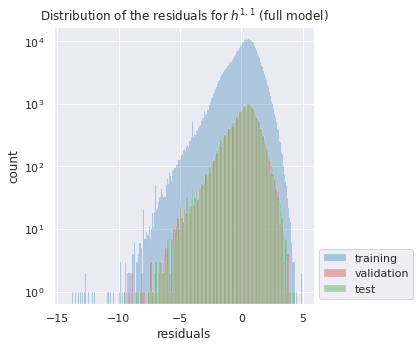

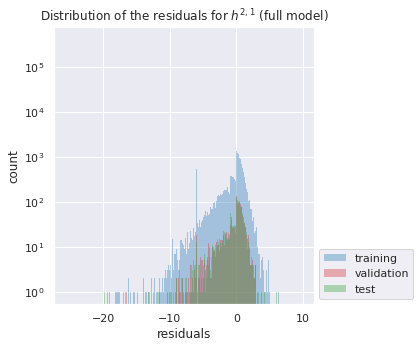

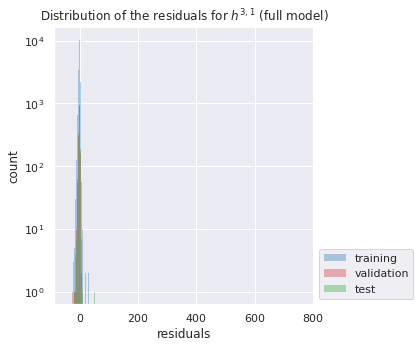

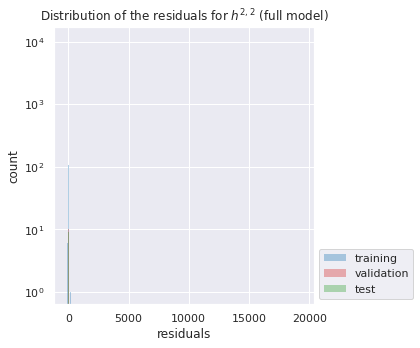

In [9]:
for label in ['h11', 'h21', 'h31', 'h22']:
    fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))
    
    sns.histplot(data=residuals['training']['full_model'][label],
                 color='tab:blue',
                 alpha=0.35,
                 stat='count',
                 ax=ax
                )
    sns.histplot(data=residuals['validation']['full_model'][label],
                 color='tab:red',
                 alpha=0.35,
                 stat='count',
                 ax=ax
                )
    sns.histplot(data=residuals['test']['full_model'][label],
                 color='tab:green',
                 alpha=0.35,
                 stat='count',
                 ax=ax
                )
    ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
    ax.set(title=f'Distribution of the residuals for {py_to_tex(label)} (full model)',
           xlabel='residuals',
           ylabel='count',
           yscale='log'
          )

    savefig('inception_full_model_' + label + '_residuals', fig, root=img_dir, show=True)
    
    if parameters['aux_output']:
        fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

        sns.histplot(data=residuals['training']['full_model'][label + '_' + parameters['aux_suff']],
                     color='tab:blue',
                     alpha=0.35,
                     stat='count',
                     ax=ax
                    )
        sns.histplot(data=residuals['validation']['full_model'][label + '_' + parameters['aux_suff']],
                     color='tab:red',
                     alpha=0.35,
                     stat='count',
                     ax=ax
                    )
        sns.histplot(data=residuals['test']['full_model'][label + '_' + parameters['aux_suff']],
                     color='tab:green',
                     alpha=0.35,
                     stat='count',
                     ax=ax
                    )
        ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
        ax.set(title=f'Distribution of the residuals for {py_to_tex(label)} (full model - auxiliary output)',
               xlabel='residuals',
               ylabel='count',
               yscale='log'
              )

        savefig('inception_full_model_' + label + '_' + parameters['aux_suff'] + '_residuals', fig, root=img_dir, show=True)

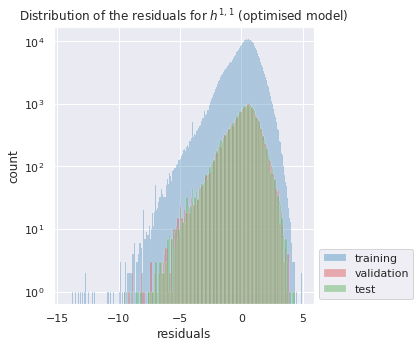

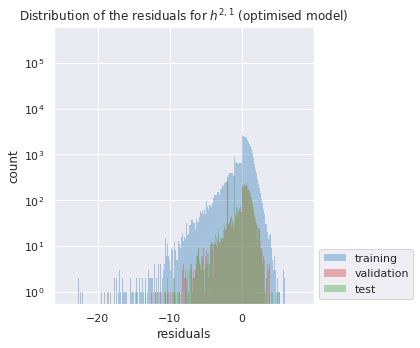

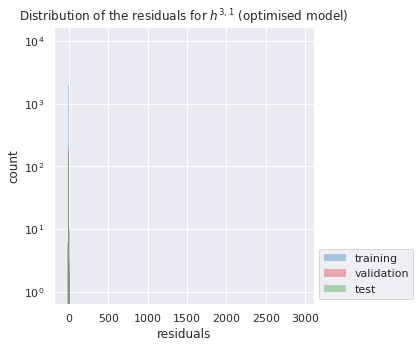

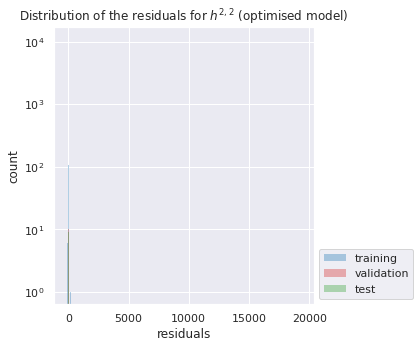

In [13]:
for label in ['h11', 'h21', 'h31', 'h22']:
    fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

    sns.histplot(data=residuals['training'][label][label],
                 color='tab:blue',
                 alpha=0.35,
                 stat='count',
                 ax=ax
                )
    sns.histplot(data=residuals['validation'][label][label],
                 color='tab:red',
                 alpha=0.35,
                 stat='count',
                 ax=ax
                )
    sns.histplot(data=residuals['test'][label][label],
                 color='tab:green',
                 alpha=0.35,
                 stat='count',
                 ax=ax
                )
    ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
    ax.set(title=f'Distribution of the residuals for {py_to_tex(label)} (optimised model)',
           xlabel='residuals',
           ylabel='count',
           yscale='log'
          )

    savefig('inception_' + label + '_model_' + label + '_residuals', fig, root=img_dir, show=True)
    
    if parameters['aux_output']:
        fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

        sns.histplot(data=residuals['training'][label][label + '_' + parameters['aux_suff']],
                     color='tab:blue',
                     alpha=0.35,
                     stat='count',
                     ax=ax
                    )
        sns.histplot(data=residuals['validation'][label][label + '_' + parameters['aux_suff']],
                     color='tab:red',
                     alpha=0.35,
                     stat='count',
                     ax=ax
                    )
        sns.histplot(data=residuals['test'][label][label + '_' + parameters['aux_suff']],
                     color='tab:green',
                     alpha=0.35,
                     stat='count',
                     ax=ax
                    )
        ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
        ax.set(title=f'Distribution of the residuals for {py_to_tex(label)} (optimised model - auxiliary output)',
               xlabel='residuals',
               ylabel='count',
               yscale='log'
              )

        savefig('inception_' + label + '_model_' + label + parameters['aux_suff'] + '_residuals', fig, root=img_dir, show=True)

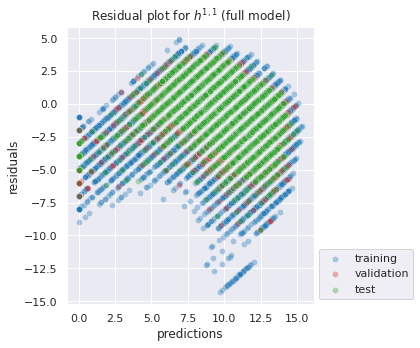

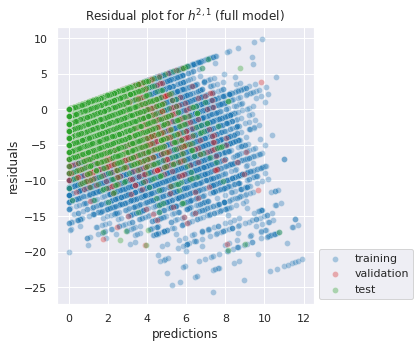

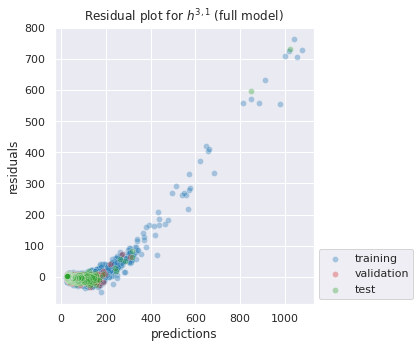

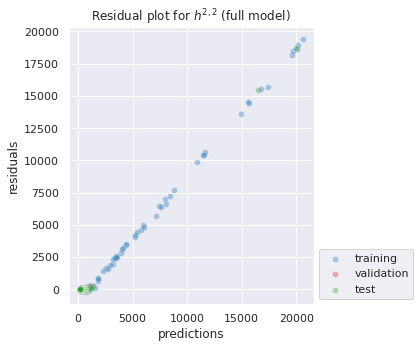

In [14]:
for label in ['h11', 'h21', 'h31', 'h22']:
    
    fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

    sns.scatterplot(x=predictions['training']['full_model'][label].reshape(-1,),
                    y=residuals['training']['full_model'][label],
                    color='tab:blue',
                    alpha=0.35,
                    ax=ax
                   )
    sns.scatterplot(x=predictions['validation']['full_model'][label].reshape(-1,),
                    y=residuals['validation']['full_model'][label],
                    color='tab:red',
                    alpha=0.35,
                    ax=ax
                   )
    sns.scatterplot(x=predictions['test']['full_model'][label].reshape(-1,),
                    y=residuals['test']['full_model'][label],
                    color='tab:green',
                    alpha=0.35,
                    ax=ax
                   )
    ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
    ax.set(title=f'Residual plot for {py_to_tex(label)} (full model)',
           xlabel='predictions',
           ylabel='residuals'
          )

    savefig('inception_full_model_' + label + '_resplot', fig, root=img_dir, show=True)
    
    if parameters['aux_output']:
        
        fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

        sns.scatterplot(x=predictions['training']['full_model'][label + '_' + parameters['aux_suff']].reshape(-1,),
                        y=residuals['training']['full_model'][label + '_' + parameters['aux_suff']],
                        color='tab:blue',
                        alpha=0.35,
                        ax=ax
                       )
        sns.scatterplot(x=predictions['validation']['full_model'][label + '_' + parameters['aux_suff']].reshape(-1,),
                        y=residuals['validation']['full_model'][label + '_' + parameters['aux_suff']],
                        color='tab:red',
                        alpha=0.35,
                        ax=ax
                       )
        sns.scatterplot(x=predictions['test']['full_model'][label + '_' + parameters['aux_suff']].reshape(-1,),
                        y=residuals['test']['full_model'][label + '_' + parameters['aux_suff']],
                        color='tab:green',
                        alpha=0.35,
                        ax=ax
                       )
        ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
        ax.set(title=f'Residual plot for {py_to_tex(label)} (full model - auxiliary output)',
               xlabel='predictions',
               ylabel='residuals'
              )

        savefig('inception_full_model_' + label + '_' + parameters['aux_suff'] + '_resplot', fig, root=img_dir, show=True)

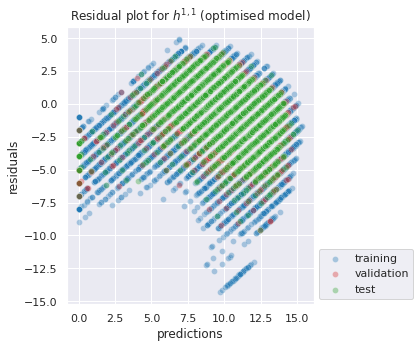

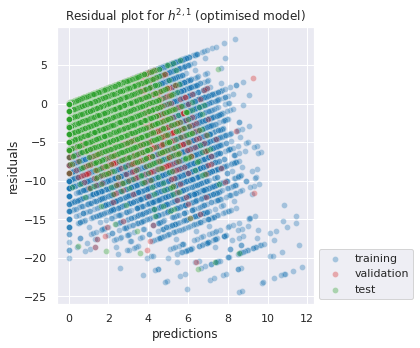

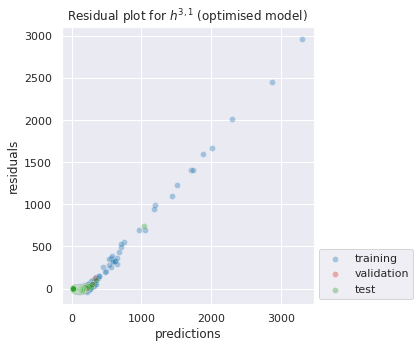

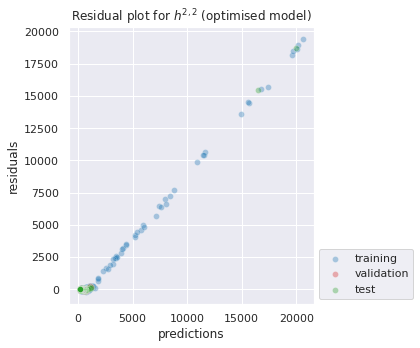

In [15]:
for label in ['h11', 'h21', 'h31', 'h22']:
    
    fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

    sns.scatterplot(x=predictions['training'][label][label].reshape(-1,),
                    y=residuals['training'][label][label],
                    color='tab:blue',
                    alpha=0.35,
                    ax=ax
                   )
    sns.scatterplot(x=predictions['validation'][label][label].reshape(-1,),
                    y=residuals['validation'][label][label],
                    color='tab:red',
                    alpha=0.35,
                    ax=ax
                   )
    sns.scatterplot(x=predictions['test'][label][label].reshape(-1,),
                    y=residuals['test'][label][label],
                    color='tab:green',
                    alpha=0.35,
                    ax=ax
                   )
    ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
    ax.set(title=f'Residual plot for {py_to_tex(label)} (optimised model)',
           xlabel='predictions',
           ylabel='residuals'
          )

    savefig('inception_' + label + '_model_' + label + '_resplot', fig, root=img_dir, show=True)
    
    if parameters['aux_output']:

        fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

        sns.scatterplot(x=predictions['training'][label][label + '_' + parameters['aux_suff']].reshape(-1,),
                        y=residuals['training'][label][label + '_' + parameters['aux_suff']],
                        color='tab:blue',
                        alpha=0.35,
                        ax=ax
                       )
        sns.scatterplot(x=predictions['validation'][label][label + '_' + parameters['aux_suff']].reshape(-1,),
                        y=residuals['validation'][label][label + '_' + parameters['aux_suff']],
                        color='tab:red',
                        alpha=0.35,
                        ax=ax
                       )
        sns.scatterplot(x=predictions['test'][label][label + '_' + parameters['aux_suff']].reshape(-1,),
                        y=residuals['test'][label][label + '_' + parameters['aux_suff']],
                        color='tab:green',
                        alpha=0.35,
                        ax=ax
                       )
        ax.legend(['training', 'validation', 'test'], bbox_to_anchor=(1.0, 0.0), loc='lower left')
        ax.set(title=f'Residual plot for {py_to_tex(label)} (optimised model - auxiliary output)',
               xlabel='predictions',
               ylabel='residuals'
              )

        savefig('inception_' + label + '_model_' + label + '_' + parameters['aux_suff'] + '_resplot', fig, root=img_dir, show=True)

## Compute the Metrics

We finally compute the metrics of the model.

In [16]:
metrics = {fold: \
           {model: \
            {'mse':       {label: np.mean(np.square(residuals[fold][model][label]))
                           for label in predictions[fold][model].keys()
                          },
             'mae':       {label: np.mean(np.abs(residuals[fold][model][label]))
                           for label in predictions[fold][model].keys()
                          },
             'acc_rint':  {label: np.equal(true_values[fold][label],
                                           np.rint(predictions[fold][model][label].reshape(-1,)).astype(np.int)
                                          ).mean()
                           for label in predictions[fold][model].keys()
                          },
             'acc_floor': {label: np.equal(true_values[fold][label],
                                          np.floor(predictions[fold][model][label].reshape(-1,)).astype(np.int)
                                         ).mean()
                           for label in predictions[fold][model].keys()
                          },
             'acc_ceil':  {label: np.equal(true_values[fold][label],
                                          np.ceil(predictions[fold][model][label].reshape(-1,)).astype(np.int)
                                         ).mean()
                           for label in predictions[fold][model].keys()
                          },
            } for model in predictions[fold].keys()
           } for fold in predictions.keys()
          }
joblib.dump(true_values, os.path.join(mod_dir, 'inception_metrics.joblib.gz'), compress=9)

['./models/inception_20201211_193827/inception_metrics.joblib.gz']

In [17]:
with open(os.path.join(mod_dir, 'metrics.txt'), 'w') as out_file:
    for file in [sys.stdout, out_file]:
        for folds, models_dict in metrics.items():
            print('\n=====================', file=file)
            print(f'{folds.upper()}:', file=file)
            print('=====================', file=file)
            for mod, metrics_dict in models_dict.items():
                print(f'\n  {mod}:', file=file)
                print('  ___________________', file=file)
                for met, labels_dict in metrics_dict.items():
                    print(f'\n    > {met.upper()}:', file=file)
                    for lab, met_value in labels_dict.items():
                        print(f'      * {lab.lower()}: {met_value:.3f}', file=file)


TRAINING:

  full_model:
  ___________________

    > MSE:
      * h11: 1.843
      * h21: 2.306
      * h31: 17.145
      * h22: 4541.855

    > MAE:
      * h11: 1.029
      * h21: 0.717
      * h31: 2.332
      * h22: 7.737

    > ACC_RINT:
      * h11: 0.312
      * h21: 0.630
      * h31: 0.152
      * h22: 0.057

    > ACC_FLOOR:
      * h11: 0.361
      * h21: 0.675
      * h31: 0.124
      * h22: 0.054

    > ACC_CEIL:
      * h11: 0.224
      * h21: 0.548
      * h31: 0.174
      * h22: 0.060

  h11:
  ___________________

    > MSE:
      * h11: 1.843
      * h21: 2.306
      * h31: 17.145
      * h22: 4541.855

    > MAE:
      * h11: 1.029
      * h21: 0.717
      * h31: 2.332
      * h22: 7.737

    > ACC_RINT:
      * h11: 0.312
      * h21: 0.630
      * h31: 0.152
      * h22: 0.057

    > ACC_FLOOR:
      * h11: 0.361
      * h21: 0.675
      * h31: 0.124
      * h22: 0.054

    > ACC_CEIL:
      * h11: 0.224
      * h21: 0.548
      * h31: 0.174
      * h22: 0.060

 